# Data Exploration — World Cup Score Predictor

This notebook explores the combined ELO match dataset.

Goals:
- Understand date coverage and competition distribution.
- Explore goals, rankings, ELO ratings, and World Cup matches.
- Identify useful patterns for feature engineering.
- Keep this notebook exploratory only — no model training.

##  Imports + Paths

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)

current = Path.cwd()

if (current / "data").exists():
    BASE_DIR = current
elif (current.parent / "data").exists():
    BASE_DIR = current.parent
else:
    raise FileNotFoundError("Could not find project root with data/ folder")

RAW_DIR = BASE_DIR / "data" / "raw"
INTERIM_DIR = BASE_DIR / "data" / "interim"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

print("BASE_DIR:", BASE_DIR)

BASE_DIR: /workspaces/World_cup_predictor


## Load Data

In [2]:
elo_files = sorted(RAW_DIR.glob("elo_*_results.csv"))

if not elo_files:
    raise FileNotFoundError("No ELO files found in data/raw")

df = pd.concat(
    [pd.read_csv(f) for f in elo_files],
    ignore_index=True
)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values("date").reset_index(drop=True)

print("Number of ELO files:", len(elo_files))
print("Shape:", df.shape)
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

display(df.head())

Number of ELO files: 26
Shape: (24260, 15)
Date range: 2001-01-04 to 2026-05-16


,date,team_a,team_b,goals_a,goals_b,competition,location,rating_change_a,rating_change_b,rating_a,rating_b,rank_change_a,rank_change_b,rank_a,rank_b
0,2001-01-04,Kenya,Zambia,2,1,Friendly,Kenya,11,-11,1339,1444,3,-5,119,91
1,2001-01-06,Costa Rica,Guatemala,5,2,World Cup qualifier,the United States,32,-32,1638,1543,5,-6,53,67
2,2001-01-06,Egypt,United Arab Emirates,2,1,Friendly,Egypt,4,-4,1686,1542,0,0,42,68
3,2001-01-06,Namibia,Lesotho,1,0,Friendly tournament,Swaziland,10,-10,1336,1186,4,-2,120,158
4,2001-01-06,Qatar,Jordan,3,1,Friendly,Qatar,10,-10,1505,1459,2,-1,76,81


## Basic Dataset Summary

In [3]:
summary = pd.DataFrame([{
    "rows": len(df),
    "teams": pd.concat([df["team_a"], df["team_b"]]).nunique(),
    "competitions": df["competition"].nunique(),
    "countries_locations": df["location"].nunique(),
    "avg_goals_a": df["goals_a"].mean(),
    "avg_goals_b": df["goals_b"].mean(),
    "avg_total_goals": (df["goals_a"] + df["goals_b"]).mean(),
}])

display(summary)

,rows,teams,competitions,countries_locations,avg_goals_a,avg_goals_b,avg_total_goals
0,24260,247,198,232,1.806801,0.892869,2.69967


##  Matches by Year

,year,matches
0,2001,1015
1,2002,779
2,2003,927
3,2004,1092
4,2005,793
5,2006,843
6,2007,988
7,2008,1114
8,2009,905
9,2010,881


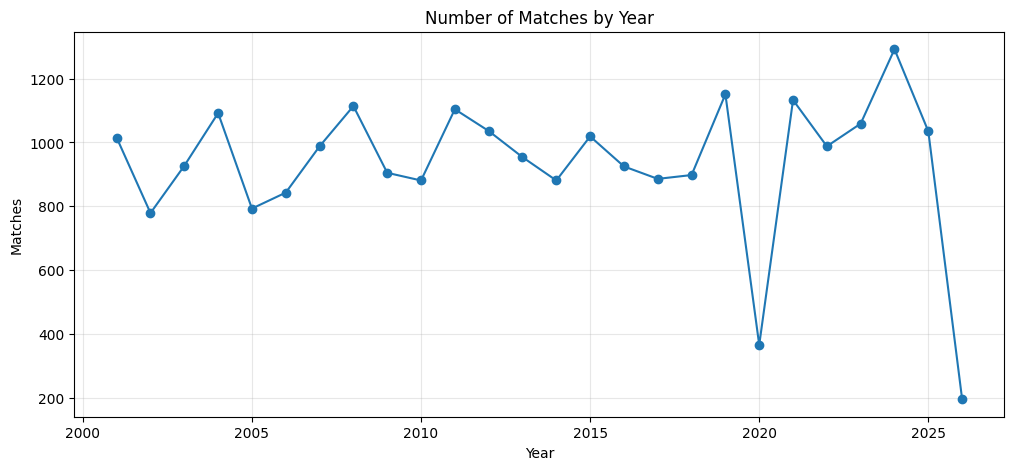

In [11]:
df["year"] = df["date"].dt.year

matches_by_year = df.groupby("year").size().reset_index(name="matches")

display(matches_by_year)

plt.figure(figsize=(12, 5))
plt.plot(matches_by_year["year"], matches_by_year["matches"], marker="o")
plt.title("Number of Matches by Year")
plt.xlabel("Year")
plt.ylabel("Matches")
plt.grid(True, alpha=0.3)
plt.show()

## Competitions Distribution

,competition,matches
0,Friendly,7823
1,World Cup qualifier,4695
2,European Championship qualifier,1533
3,African Nations Cup qualifier,1371
4,African Nations Cup,493
5,Asian Cup qualifier,491
6,World Cup and Asian Cup qualifier,454
7,World Cup and African Cup qualifier,385
8,World Cup,384
9,COSAFA Cup,371


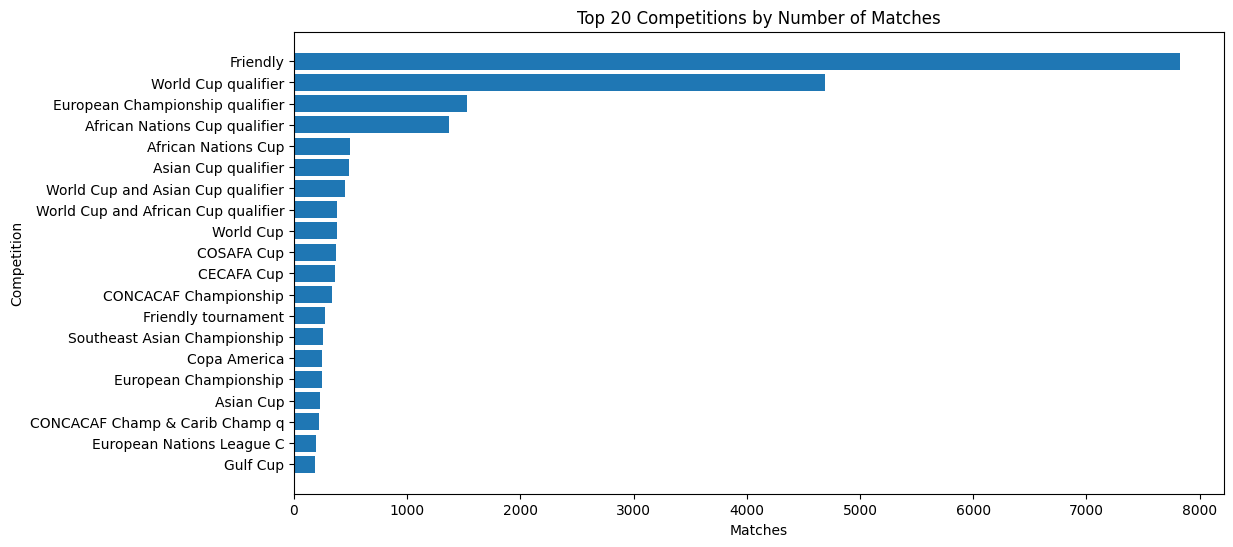

In [5]:
top_competitions = (
    df["competition"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_competitions.columns = ["competition", "matches"]

display(top_competitions)

plt.figure(figsize=(12, 6))
plt.barh(top_competitions["competition"][::-1], top_competitions["matches"][::-1])
plt.title("Top 20 Competitions by Number of Matches")
plt.xlabel("Matches")
plt.ylabel("Competition")
plt.show()

## Goals Distribution

,goals_a,goals_b,total_goals,goal_diff
count,24260.000000,24260.000000,24260.000000,24260.000000
mean,1.806801,0.892869,2.699670,0.913932
std,1.699454,1.103539,1.906377,2.139535
min,0.000000,0.000000,0.000000,-13.000000
25%,1.000000,0.000000,1.000000,0.000000
50%,1.000000,1.000000,2.000000,1.000000
75%,3.000000,1.000000,4.000000,2.000000
max,31.000000,13.000000,31.000000,31.000000


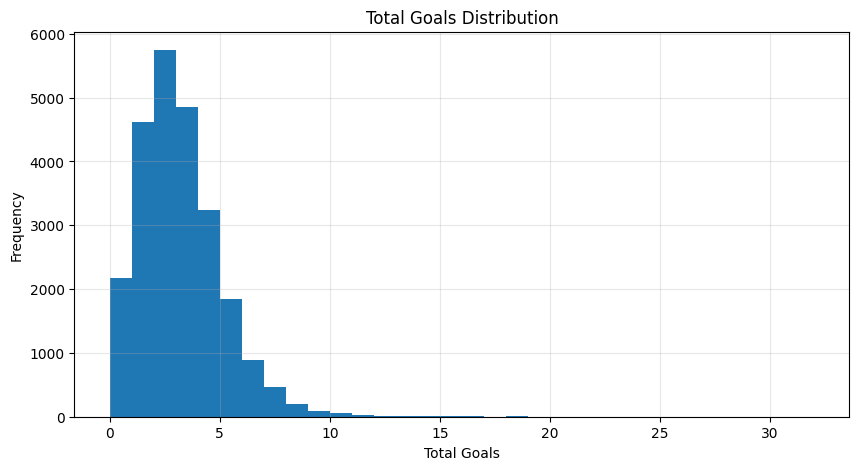

In [6]:
df["total_goals"] = df["goals_a"] + df["goals_b"]
df["goal_diff"] = df["goals_a"] - df["goals_b"]

goals_summary = df[["goals_a", "goals_b", "total_goals", "goal_diff"]].describe()

display(goals_summary)

plt.figure(figsize=(10, 5))
plt.hist(df["total_goals"], bins=range(0, int(df["total_goals"].max()) + 2))
plt.title("Total Goals Distribution")
plt.xlabel("Total Goals")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

## ELO and Rank Before Match

,rating_a_before,rating_b_before,elo_diff,rank_a_before,rank_b_before,rank_diff
count,24260.000000,24260.000000,24260.000000,24260.000000,24260.000000,24260.000000
mean,1508.166200,1456.540725,51.625474,83.367890,95.444971,-12.077082
std,295.450591,316.951737,278.290673,57.972957,61.444160,55.014926
min,334.000000,335.000000,-1238.000000,-3.000000,-3.000000,-204.000000
25%,1319.000000,1274.750000,-121.000000,34.000000,44.000000,-45.000000
50%,1527.000000,1490.000000,51.000000,74.000000,87.000000,-13.000000
75%,1726.000000,1687.000000,224.000000,125.000000,142.000000,20.000000
max,2223.000000,2199.000000,1349.000000,243.000000,244.000000,204.000000


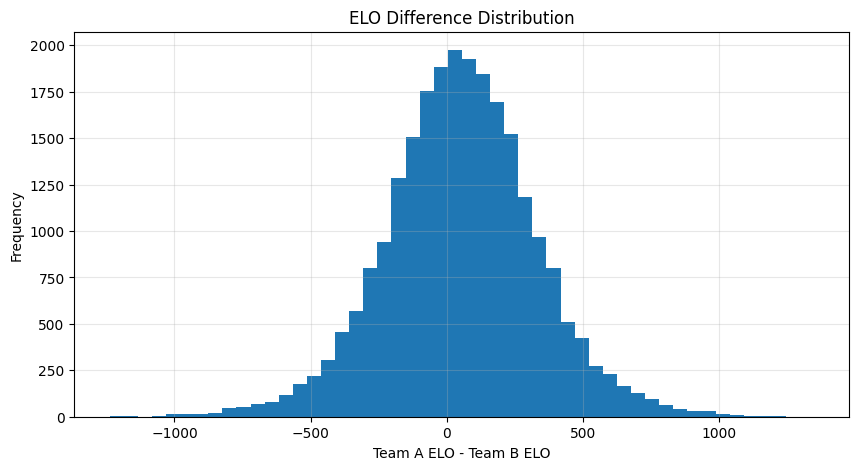

In [7]:
df["rating_a_before"] = df["rating_a"] - df["rating_change_a"]
df["rating_b_before"] = df["rating_b"] - df["rating_change_b"]

df["rank_a_before"] = df["rank_a"] - df["rank_change_a"]
df["rank_b_before"] = df["rank_b"] - df["rank_change_b"]

df["elo_diff"] = df["rating_a_before"] - df["rating_b_before"]
df["rank_diff"] = df["rank_a_before"] - df["rank_b_before"]

display(df[[
    "rating_a_before",
    "rating_b_before",
    "elo_diff",
    "rank_a_before",
    "rank_b_before",
    "rank_diff"
]].describe())

plt.figure(figsize=(10, 5))
plt.hist(df["elo_diff"], bins=50)
plt.title("ELO Difference Distribution")
plt.xlabel("Team A ELO - Team B ELO")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

## Result Distribution

,result,share
0,team_a_win,0.573743
1,draw,0.236645
2,team_b_win,0.189613


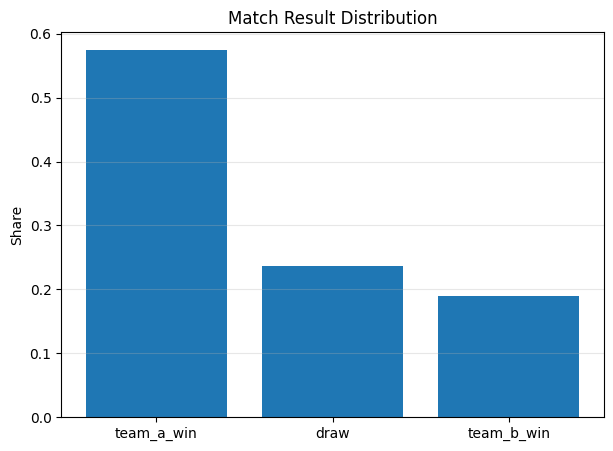

In [8]:
df["result"] = np.select(
    [
        df["goals_a"] > df["goals_b"],
        df["goals_a"] == df["goals_b"],
        df["goals_a"] < df["goals_b"],
    ],
    [
        "team_a_win",
        "draw",
        "team_b_win",
    ],
    default="unknown"
)

result_dist = df["result"].value_counts(normalize=True).reset_index()
result_dist.columns = ["result", "share"]

display(result_dist)

plt.figure(figsize=(7, 5))
plt.bar(result_dist["result"], result_dist["share"])
plt.title("Match Result Distribution")
plt.ylabel("Share")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

##  World Cup Matches

In [9]:
world_cup_df = df[
    df["competition"].astype(str).str.lower().eq("world cup")
].copy()

world_cup_df["world_cup_year"] = world_cup_df["date"].dt.year

wc_summary = (
    world_cup_df
    .groupby("world_cup_year")
    .agg(
        matches=("date", "count"),
        avg_total_goals=("total_goals", "mean"),
        avg_goal_diff=("goal_diff", "mean")
    )
    .reset_index()
)

display(wc_summary)

display(world_cup_df[[
    "date", "team_a", "team_b", "goals_a", "goals_b", "competition"
]].head(20))

,world_cup_year,matches,avg_total_goals,avg_goal_diff
0,2002,64,2.515625,1.203125
1,2006,64,2.296875,1.359375
2,2010,64,2.265625,1.140625
3,2014,64,2.671875,1.140625
4,2018,64,2.640625,1.203125
5,2022,64,2.687500,1.218750


,date,team_a,team_b,goals_a,goals_b,competition
1322,2002-05-31,Senegal,France,1,0,World Cup
1323,2002-06-01,Cameroon,Ireland,1,1,World Cup
1324,2002-06-01,Denmark,Uruguay,2,1,World Cup
1325,2002-06-01,Germany,Saudi Arabia,8,0,World Cup
1326,2002-06-02,Argentina,Nigeria,1,0,World Cup
1327,2002-06-02,England,Sweden,1,1,World Cup
1328,2002-06-02,Paraguay,South Africa,2,2,World Cup
1329,2002-06-02,Spain,Slovenia,3,1,World Cup
1330,2002-06-03,Brazil,Turkey,2,1,World Cup
1331,2002-06-03,Italy,Ecuador,2,0,World Cup


##  Market Value Coverage

In [10]:
market_path = PROCESSED_DIR / "transfermarkt_market_values_clean.csv"

if market_path.exists():
    tm = pd.read_csv(market_path)

    tm_summary = pd.DataFrame([{
        "rows": len(tm),
        "teams": tm["team_name_tm"].nunique(),
        "first_year": tm["season_id"].min(),
        "last_year": tm["season_id"].max(),
        "missing_market_value_share": (tm["squad_market_value_millions_eur"] <= 0).mean(),
    }])

    display(tm_summary)

    top_market = (
        tm[tm["season_id"] == tm["season_id"].max()]
        .sort_values("squad_market_value_millions_eur", ascending=False)
        .head(20)
    )

    display(top_market[[
        "team_name_tm",
        "season_id",
        "squad_market_value_millions_eur",
        "avg_player_value_millions_eur"
    ]])

else:
    print("Transfermarkt clean file not found. Skipping market value EDA.")

,rows,teams,first_year,last_year,missing_market_value_share
0,5014,218,2004,2026,0.242521


,team_name_tm,season_id,squad_market_value_millions_eur,avg_player_value_millions_eur
1540,France,2026,1473.00,56.65
1333,England,2026,1315.00,50.58
4231,Spain,2026,1271.00,48.88
1632,Germany,2026,1005.50,38.67
3587,Portugal,2026,965.00,37.12
620,Brazil,2026,905.20,34.82
3104,Netherlands,2026,763.00,30.52
183,Argentina,2026,762.50,26.29
3357,Norway,2026,586.50,22.56
436,Belgium,2026,558.20,21.47


## Key EDA Takeaways

- The dataset contains international matches across many competitions and years.
- ELO and rank differences are expected to be core predictive signals.
- World Cup matches are a small but important subset, so evaluation should use World Cup-specific backtesting.
- Transfermarkt market value data is available from 2004 onward and can add squad-quality information beyond ELO.
- Feature engineering should avoid leakage by using only pre-match information.